### Zero-Shot Learning: Polymer Evaluation

- Goal: Direct evaluation of the pre-trained master_mol_dnn_model.pth on the polymer dataset without any further training or weight updates.

## 1. Cell 1: GPU Availability Check
Run this cell to ensure your A100 is visible and we select the one with the most free memory.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# GPU Selection
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"🧠 Using Device: {device}")

# Paths for Zero-Shot
PATHS = {
    "teacher_weights": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Zeroshot_Model/master_mol_dnn_model.pth",
    "optuna_study": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Zeroshot_Model/mol_dnn_optuna_best_study.pkl",
    "polymer_data": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Zeroshot_Model/POL_DNN_processed.pt",
    "output_dir": "plots_zeroshot"
}

if not os.path.exists(PATHS["output_dir"]):
    os.makedirs(PATHS["output_dir"])

# Load Hyperparameters from the Organic Study
study = joblib.load(PATHS["optuna_study"])
best_params = study.best_params
print(f"✅ Loaded Hyperparameters from Trial #{study.best_trial.number}")

🧠 Using Device: cuda:3
✅ Loaded Hyperparameters from Trial #836


/home/sunil/.cache/pypoetry/virtualenvs/poetry-demo-9b10jFFD-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cell 2: Model Architecture & Loading
The architecture must be an exact clone of the Organic Teacher for the weights to fit.

In [2]:
def get_activation(name, nodes=None):
    if name == "ReLU": return nn.ReLU()
    if name == "Mish": return nn.Mish()
    if name == "SiLU": return nn.SiLU()
    if name == "PReLU": return nn.PReLU(num_parameters=nodes)
    return nn.ReLU()

class DynamicNet(nn.Module):
    def __init__(self, input_dim, layers, dropout_rate, activation_name):
        super(DynamicNet, self).__init__()
        all_layers = []
        curr_dim = input_dim
        for nodes in layers:
            all_layers.append(nn.Linear(curr_dim, nodes))
            all_layers.append(nn.BatchNorm1d(nodes))
            all_layers.append(get_activation(activation_name, nodes))
            all_layers.append(nn.Dropout(dropout_rate))
            curr_dim = nodes
        all_layers.append(nn.Linear(curr_dim, 1))
        self.model = nn.Sequential(*all_layers)
        
    def forward(self, x):
        return self.model(x)

# Reconstruct Model Structure
layers = [best_params[f"n_units_l{i}"] for i in range(best_params["n_layers"])]
model = DynamicNet(601, layers, best_params["dropout"], best_params["activation"]).to(device)

# Load Pre-trained Weights
model.load_state_dict(torch.load(PATHS["teacher_weights"], map_location=device))
model.eval()
print("🏆 Pre-trained Teacher Model Loaded successfully.")

🏆 Pre-trained Teacher Model Loaded successfully.


### Cell 3: Polymer Data Loading
We load the polymer tensor and prepare it for prediction.

In [3]:
# Dataset Class
class MolDataset(Dataset):
    def __init__(self, fps, time, targets):
        self.features = torch.cat([torch.tensor(fps), torch.tensor(time).unsqueeze(1)], dim=1).float()
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.features[idx], self.targets[idx]

# Load Bundle
poly_bundle = torch.load(PATHS["polymer_data"], map_location='cpu')
poly_fps = poly_bundle['fingerprints'].numpy()
poly_time = poly_bundle['time_day'].numpy()
poly_targets = poly_bundle['biodegradation'].numpy()

poly_ds = MolDataset(poly_fps, poly_time, poly_targets)
poly_loader = DataLoader(poly_ds, batch_size=len(poly_ds))
print(f"🧪 Polymer Data Ready: {len(poly_fps)} points.")

🧪 Polymer Data Ready: 80 points.


🧪 Analyzing 80 Polymer data points...
💾 Plot saved to: plots_zeroshot/Polymer_Only_TSNE.png


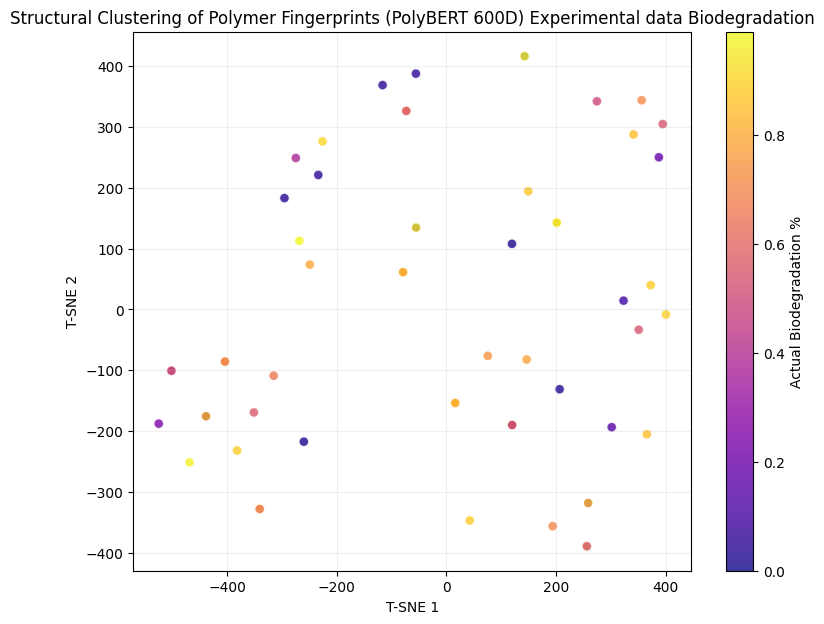

In [9]:
from sklearn.manifold import TSNE

# 1. Load Polymer Bundle (Already loaded in your previous cell, but keeping for safety)
poly_bundle = torch.load(PATHS["polymer_data"], map_location='cpu')
p_fps = poly_bundle['fingerprints'].numpy()
p_targets = poly_bundle['biodegradation'].numpy()

print(f"🧪 Analyzing {len(p_fps)} Polymer data points...")

# 2. Structural Visualization (T-SNE)
# Note: With only 80 points, we use a lower perplexity
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
p_tsne = tsne.fit_transform(p_fps)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(p_tsne[:, 0], p_tsne[:, 1], c=p_targets, cmap='plasma', alpha=0.8, edgecolors='w', s=50)
plt.colorbar(scatter, label='Actual Biodegradation %')
plt.title("Structural Clustering of Polymer Fingerprints (PolyBERT 600D) Experimental data Biodegradation")
plt.xlabel("T-SNE 1")
plt.ylabel("T-SNE 2")
plt.grid(True, alpha=0.2)

# Fixed the KeyError by using the correct key: "output_dir"
save_path = os.path.join(PATHS["output_dir"], "Polymer_Only_TSNE.png")
plt.savefig(save_path, dpi=300)
print(f"💾 Plot saved to: {save_path}")
plt.show()

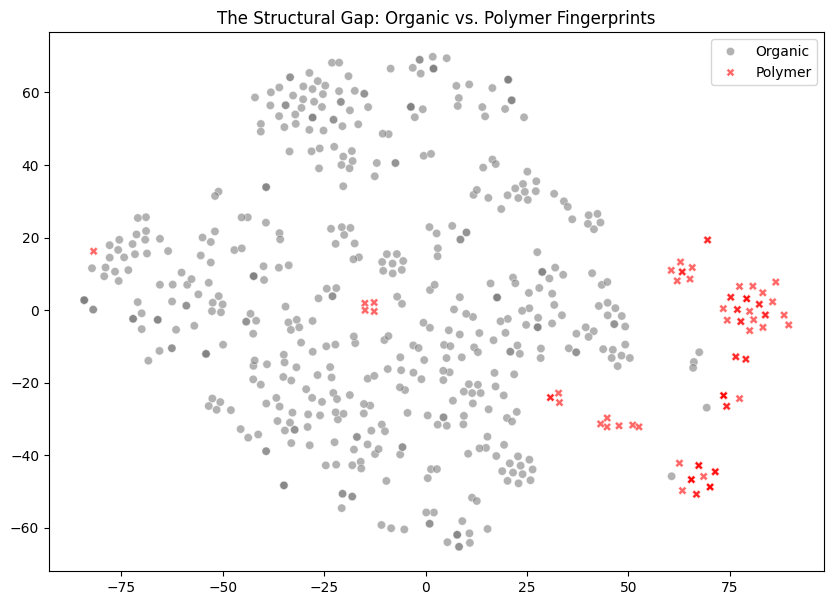

In [8]:
# Load a small sample of Organic FPs for comparison
organic_bundle = torch.load("/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Zeroshot_Model/MOL_DNN_processed.pt", map_location='cpu')
o_fps = organic_bundle['fingerprints'].numpy()[:500] # Just 500 for speed

# Combine and project
combined_fps = np.vstack([o_fps, p_fps])
labels = (['Organic'] * len(o_fps)) + (['Polymer'] * len(p_fps))

tsne_combined = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(combined_fps)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_combined[:,0], y=tsne_combined[:,1], hue=labels, style=labels, palette=['gray', 'red'], alpha=0.6)
plt.title("The Structural Gap: Organic vs. Polymer Fingerprints")
plt.savefig(os.path.join(PATHS["output_dir"], "Structural_Gap_TSNE.png"))
plt.show()

### Cell 4: Zero-Shot Performance & Parity Plot
Now we see how the Organic Model predicts Polymers without ever seeing a single plastic molecule during training.


🚀 ZERO-SHOT POLYMER EVALUATION
📊 R² Score: -0.5785
📉 RMSE:     0.4151
📏 MAE:      0.3463


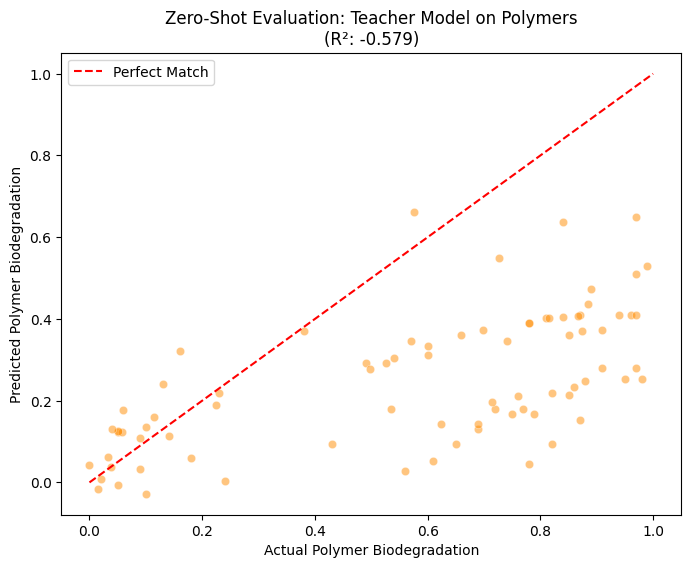

In [ ]:
with torch.no_grad():
    for bx, by in poly_loader:
        preds = model(bx.to(device)).cpu().numpy().flatten()
        actuals = by.numpy().flatten()

r2 = r2_score(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)

print("\n" + "="*50)
print("🚀 ZERO-SHOT POLYMER EVALUATION")
print("="*50)
print(f"📊 R² Score: {r2:.4f}")
print(f"📉 RMSE:     {rmse:.4f}")
print(f"📏 MAE:      {mae:.4f}")
print("="*50)

# Plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actuals, y=preds, alpha=0.5, color='darkorange')
plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")
plt.title(f"Zero-Shot Evaluation: Polymers\n(R²: {r2:.3f})")
plt.xlabel("Actual Polymer Biodegradation")
plt.ylabel("Predicted Polymer Biodegradation")
plt.legend()
plt.savefig(os.path.join(PATHS["output_dir"], "ZeroShot_Parity_Plot.png"))
plt.show()